# Notebook 4 - Relatorio Analitico e Decisao

Compara a criticidade de estoque prevista, os limiares de alerta/crítico e a necessidade de compra por modelo.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "two_stage_common.py").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
else:
    sys.path.insert(0, str((Path("data") / "notebooks").resolve()))

from two_stage_common import list_expected_artifacts, run_comparison_notebook

## Artefatos carregados

In [2]:
artifacts = list_expected_artifacts()
display(artifacts)

,artifact,size_mb
0,01_knn_gradient_boosting_regressor_threshold_m...,0.149335
1,01_knn_knn_regressor_threshold_model.pkl,61.429580
2,01_knn_xgboost_regressor_threshold_model.pkl,0.431334
3,02_linear_gradient_boosting_regressor_threshol...,0.149335
4,02_linear_linear_regression_threshold_model.pkl,0.015810
5,02_linear_xgboost_regressor_threshold_model.pkl,0.431334
6,03_tree_ensembles_gradient_boosting_regressor_...,0.149335
7,03_tree_ensembles_random_forest_regressor_thre...,152.240024
8,03_tree_ensembles_xgboost_regressor_threshold_...,0.431334
9,01_knn_gradient_boosting_classifier_purchase_a...,0.148160


## Ranking estrategico: criticidade prevista e limiares

Modelos PKL carregados: 18


,rank_estrategico,notebook,family,stage,pipeline,model,rmse,mae,r2,accuracy,...,roc_auc,average_precision,f1_macro,precision_macro,recall_macro,taxa_ok,taxa_alerta_compra,taxa_necessita_compra,limiar_alerta_predito_medio,limiar_critico_predito_medio
0,1,03_tree_ensembles,Arvores,purchase_alert_classification,Arvores - purchase_alert_classification - Rand...,Random Forest Classifier,NaN,NaN,NaN,0.997999,...,0.999961,0.999779,0.996173,0.996173,0.996173,0.845318,0.154682,0.154682,NaN,NaN
1,2,02_linear,Linear,purchase_alert_classification,Linear - purchase_alert_classification - Gradi...,Gradient Boosting Classifier,NaN,NaN,NaN,0.997570,...,0.999796,0.994169,0.995362,0.994432,0.996297,0.844603,0.155397,0.155397,NaN,NaN
2,3,01_knn,Distancia,purchase_alert_classification,Distancia - purchase_alert_classification - Gr...,Gradient Boosting Classifier,NaN,NaN,NaN,0.997570,...,0.999796,0.994169,0.995362,0.994432,0.996297,0.844603,0.155397,0.155397,NaN,NaN
3,4,03_tree_ensembles,Arvores,purchase_alert_classification,Arvores - purchase_alert_classification - Grad...,Gradient Boosting Classifier,NaN,NaN,NaN,0.997570,...,0.999796,0.994169,0.995362,0.994432,0.996297,0.844603,0.155397,0.155397,NaN,NaN
4,5,01_knn,Distancia,purchase_alert_classification,Distancia - purchase_alert_classification - Xg...,XGBoost Classifier,NaN,NaN,NaN,0.997570,...,0.999960,0.999782,0.995345,0.996285,0.994409,0.846033,0.153967,0.153967,NaN,NaN
5,6,02_linear,Linear,purchase_alert_classification,Linear - purchase_alert_classification - Xgboost,XGBoost Classifier,NaN,NaN,NaN,0.997570,...,0.999960,0.999782,0.995345,0.996285,0.994409,0.846033,0.153967,0.153967,NaN,NaN
6,7,03_tree_ensembles,Arvores,purchase_alert_classification,Arvores - purchase_alert_classification - Xgboost,XGBoost Classifier,NaN,NaN,NaN,0.997570,...,0.999960,0.999782,0.995345,0.996285,0.994409,0.846033,0.153967,0.153967,NaN,NaN
7,8,02_linear,Linear,purchase_alert_classification,Linear - purchase_alert_classification - Linear,Logistic Regression,NaN,NaN,NaN,0.985132,...,0.998877,0.992742,0.972056,0.964284,0.980257,0.838742,0.161258,0.161258,NaN,NaN
8,9,01_knn,Distancia,purchase_alert_classification,Distancia - purchase_alert_classification - Knn,KNN Classifier,NaN,NaN,NaN,0.982988,...,0.990533,0.969034,0.966934,0.974913,0.959356,0.851465,0.148535,0.148535,NaN,NaN
9,10,03_tree_ensembles,Arvores,threshold_regression,Arvores - threshold_regression - Random Forest,Random Forest Regressor,0.046893,0.035387,0.775765,0.998713,...,NaN,NaN,0.997543,0.996981,0.998106,0.844889,0.155111,0.155111,0.328408,0.178408


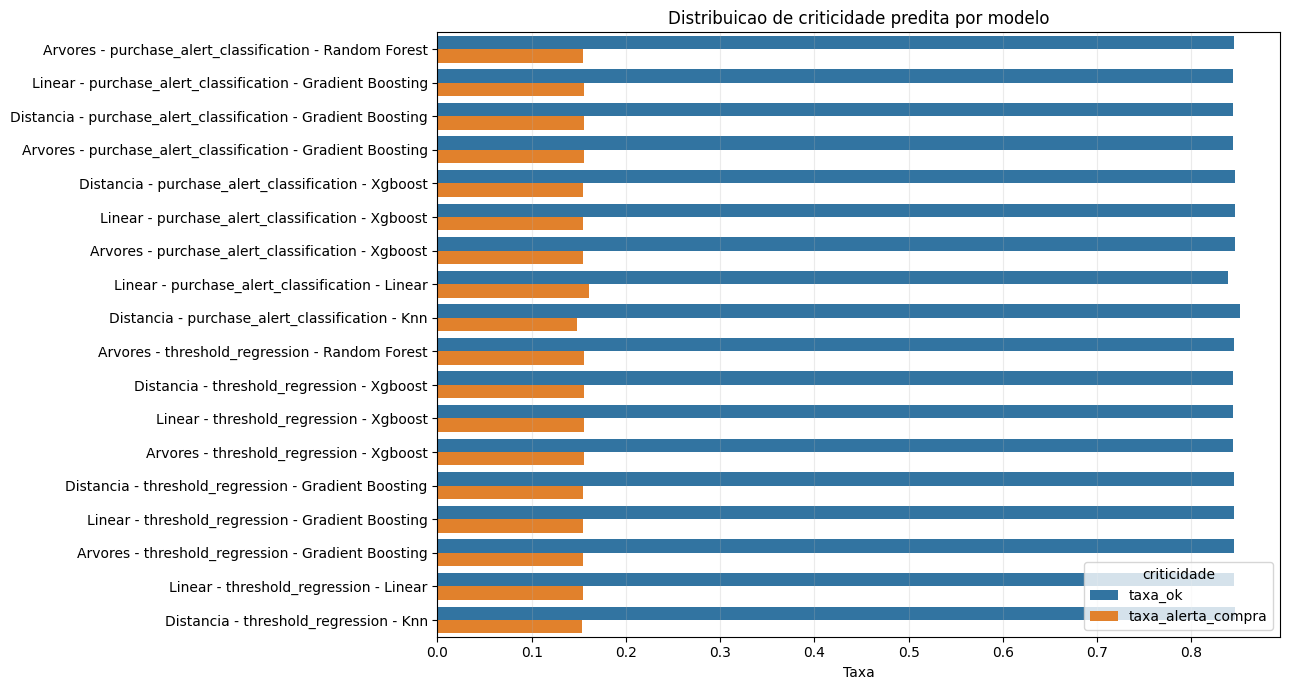

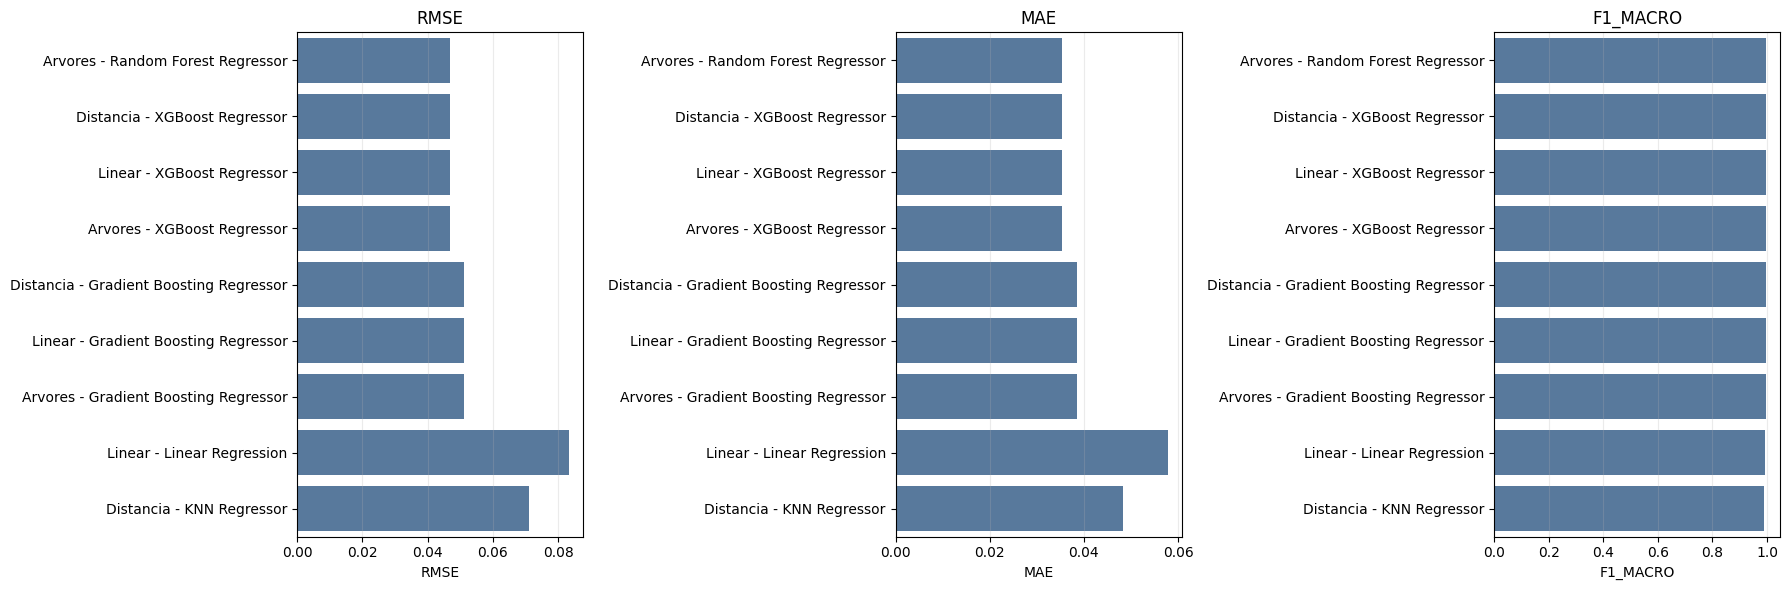

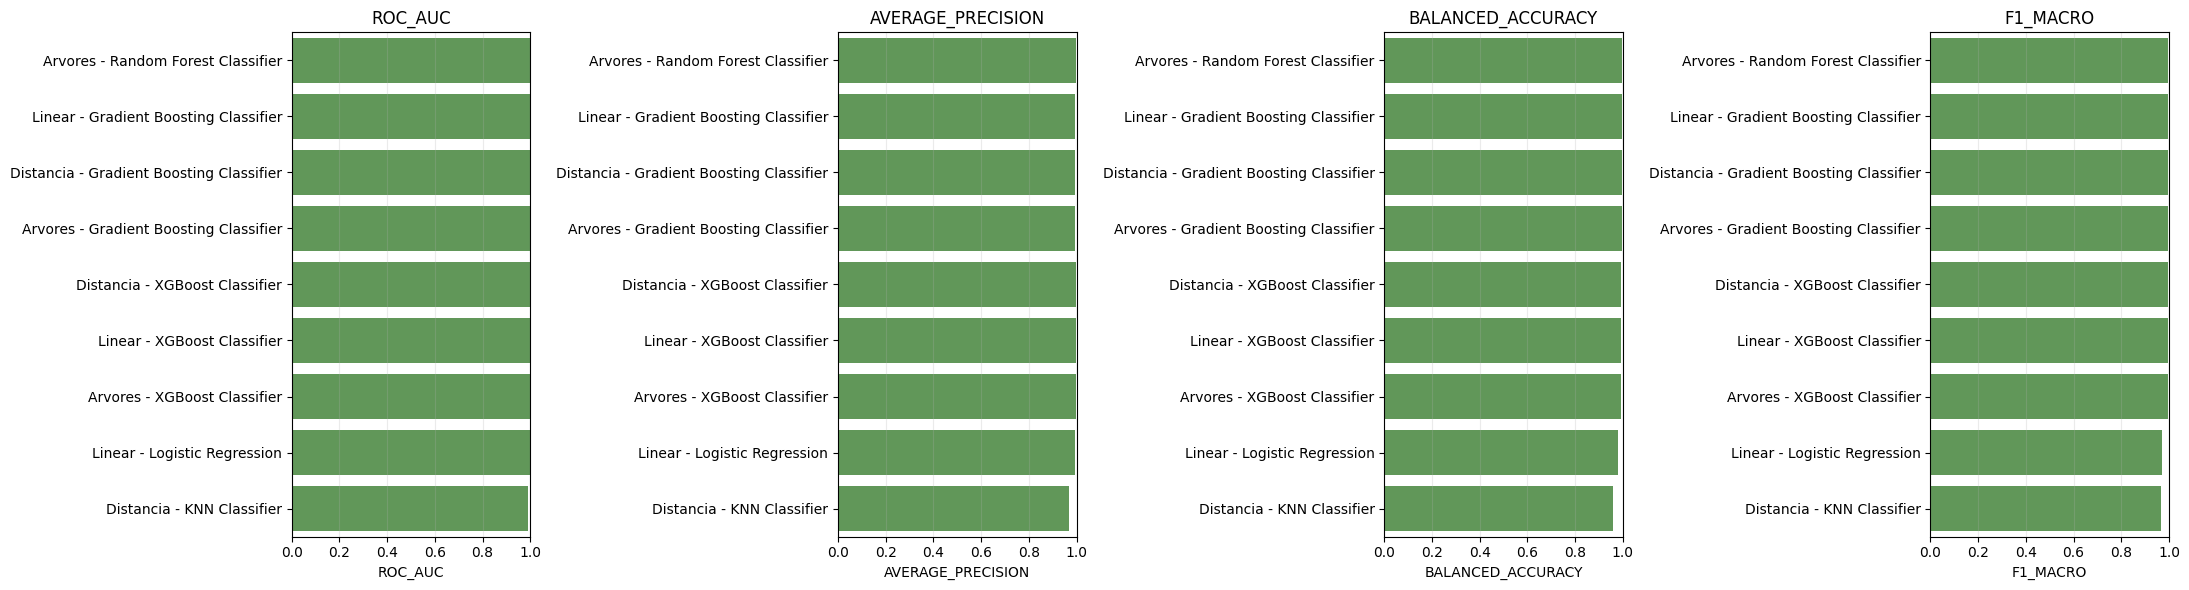

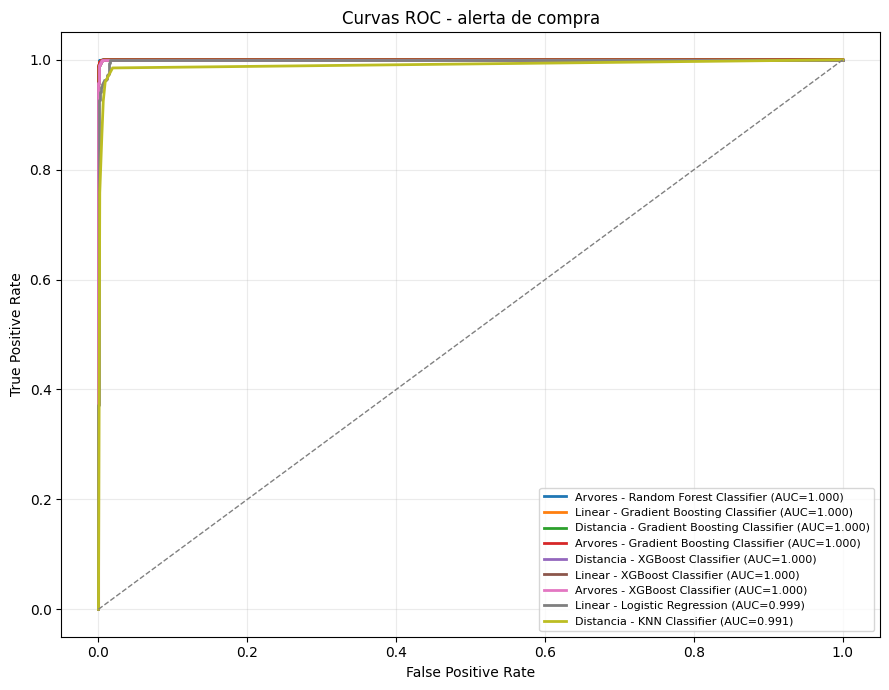

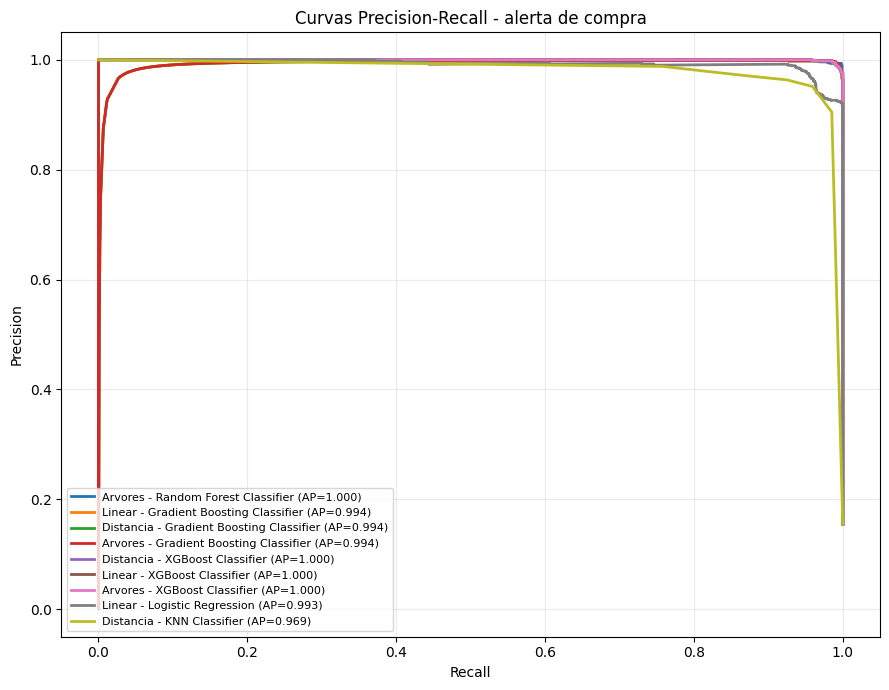

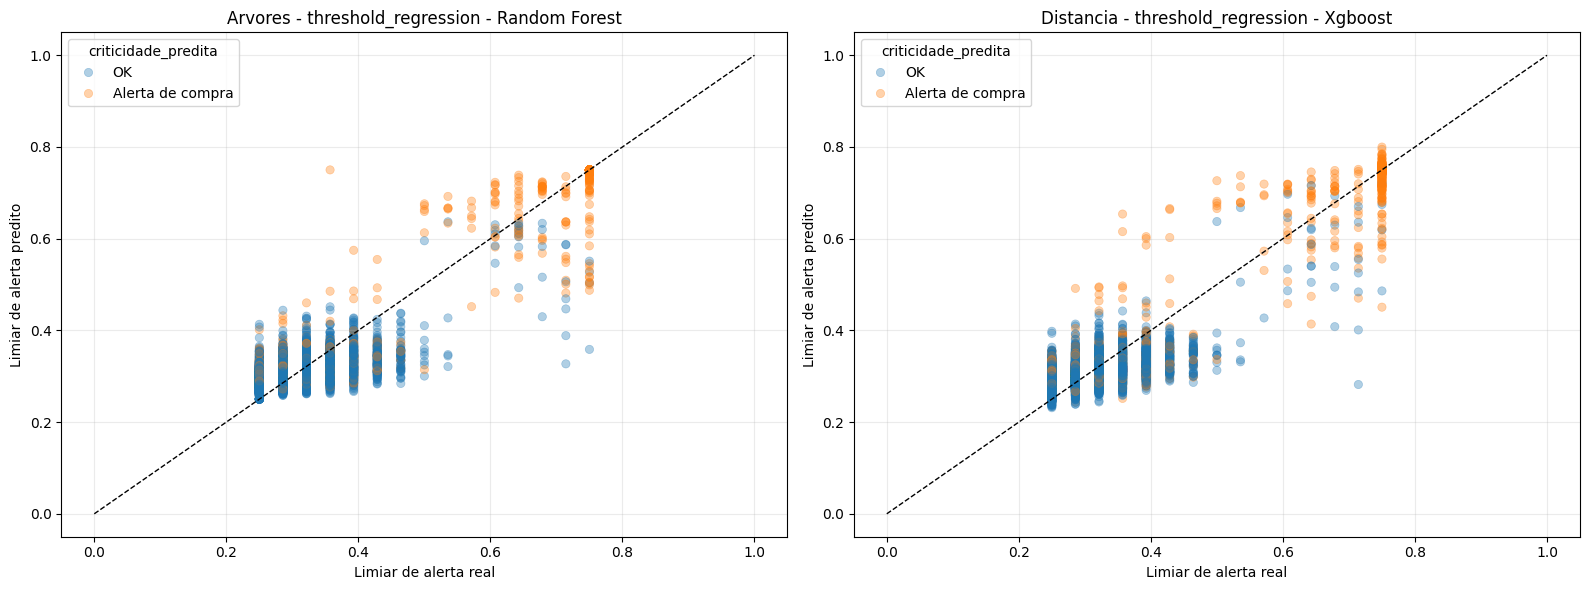

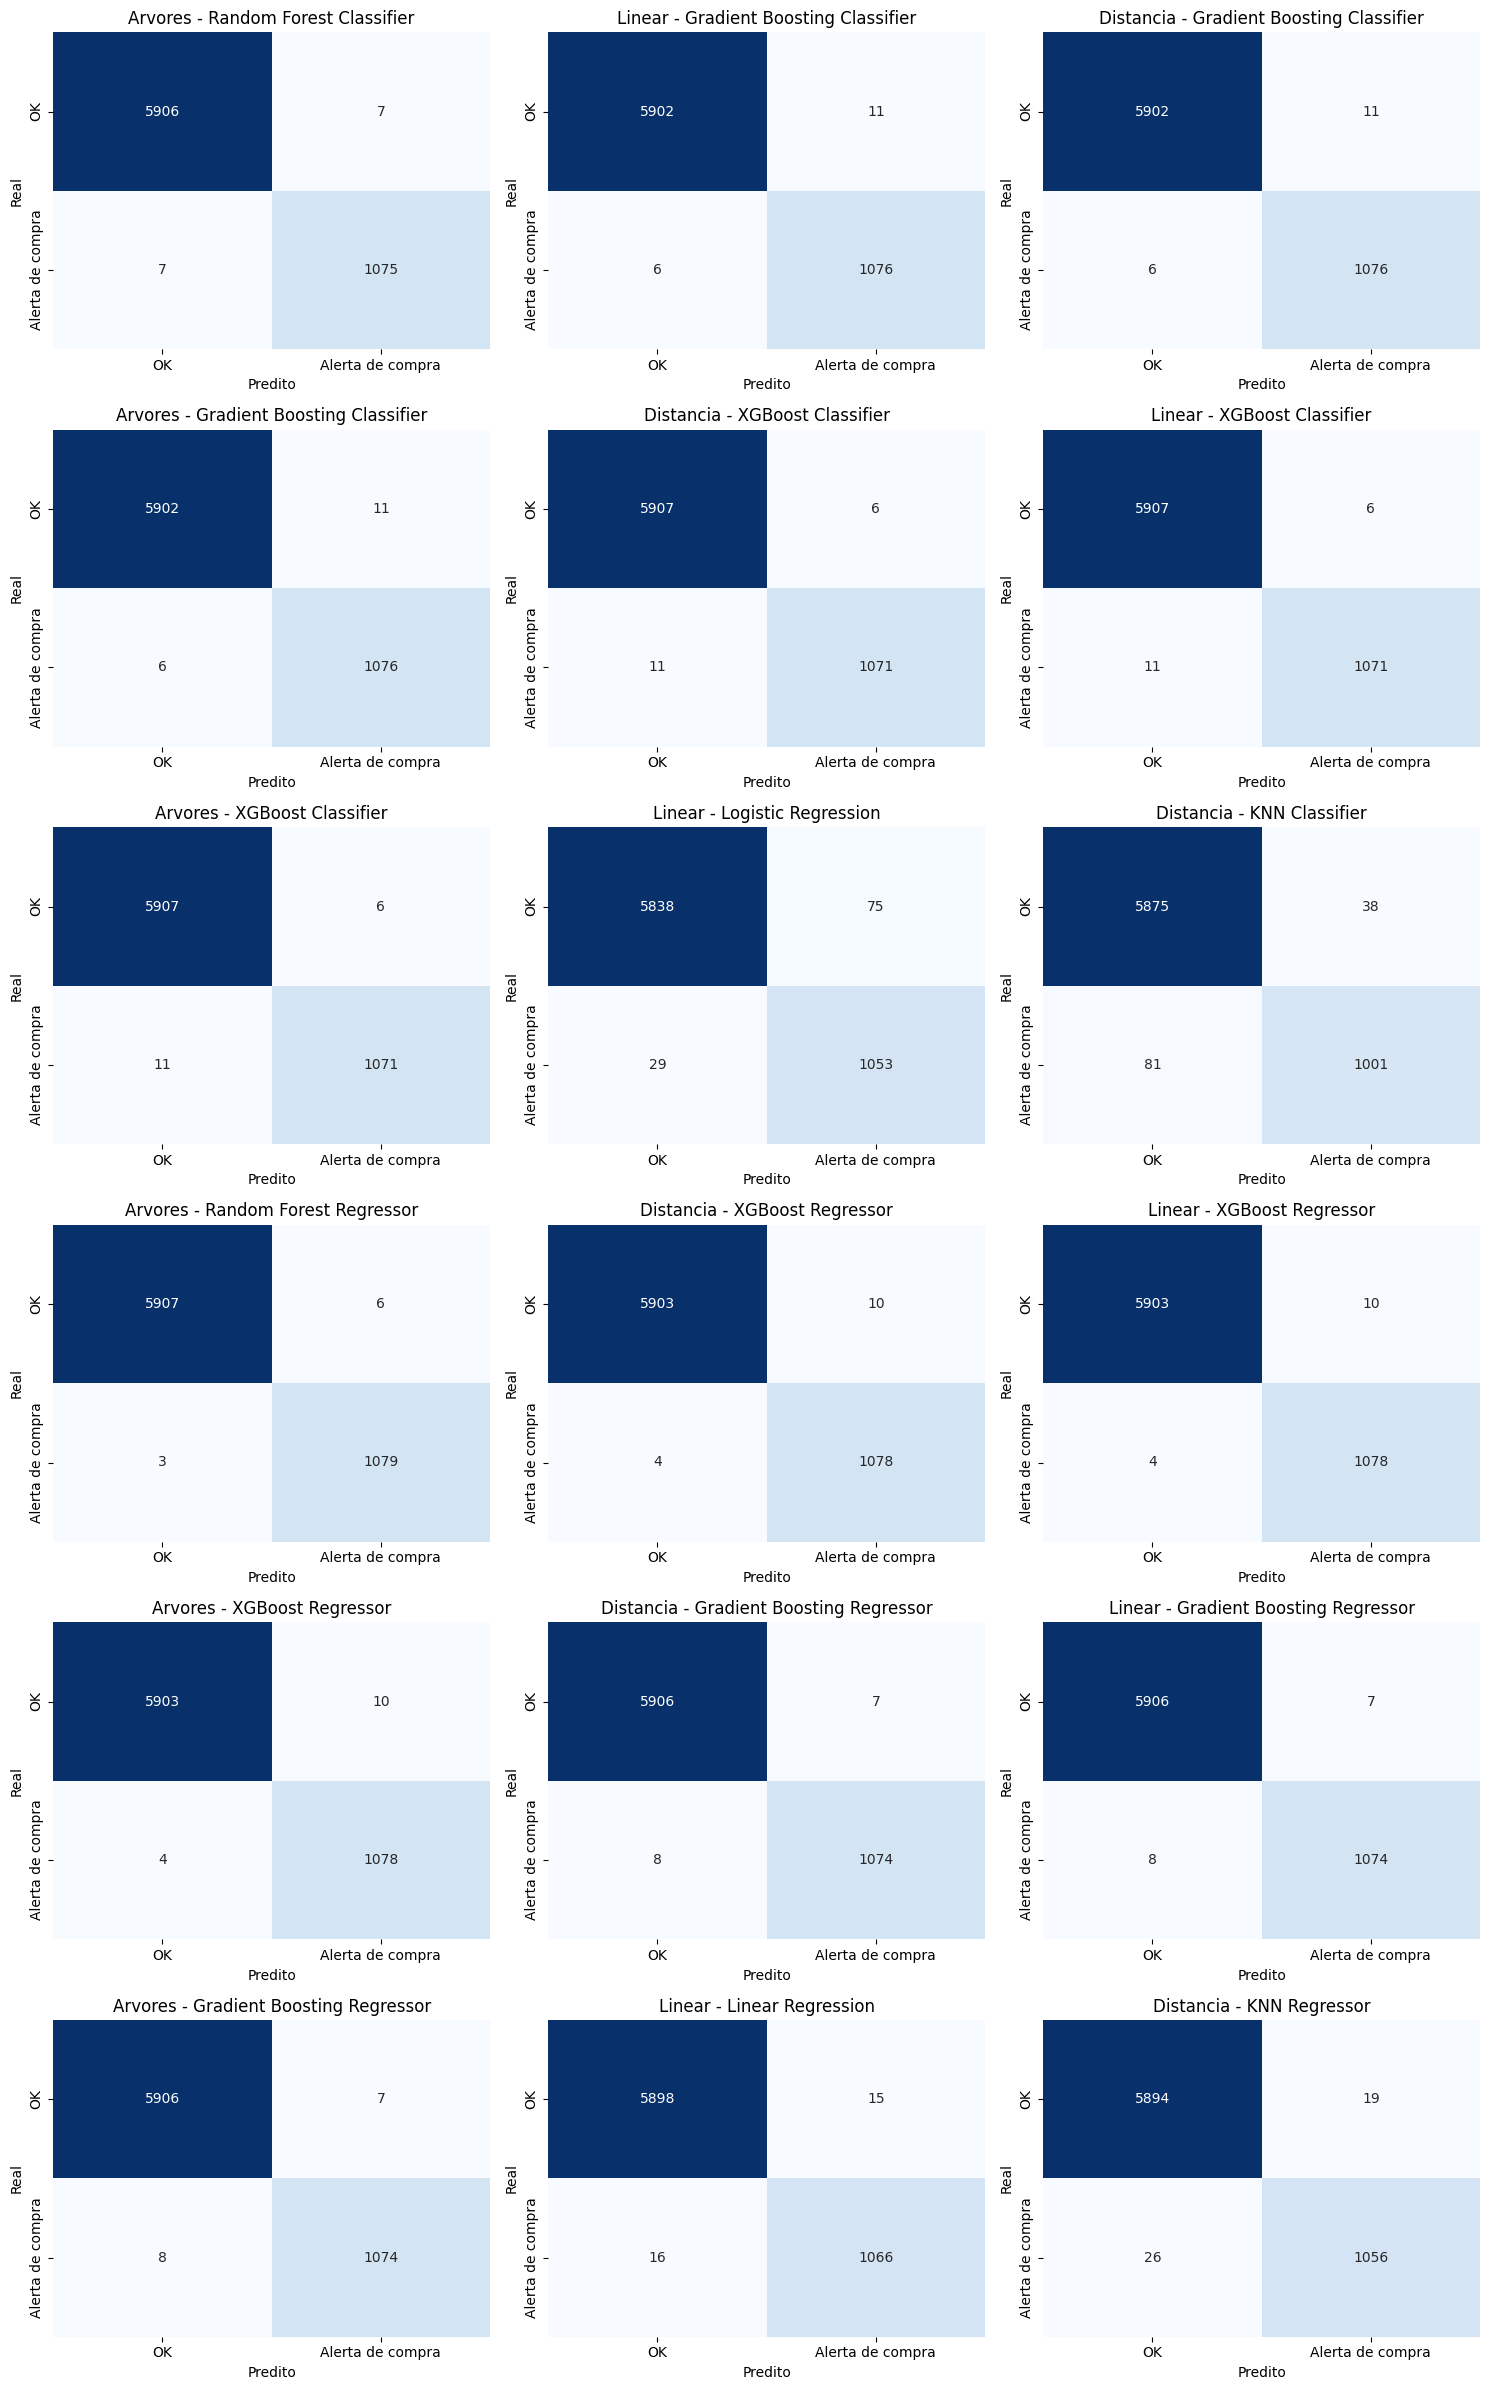

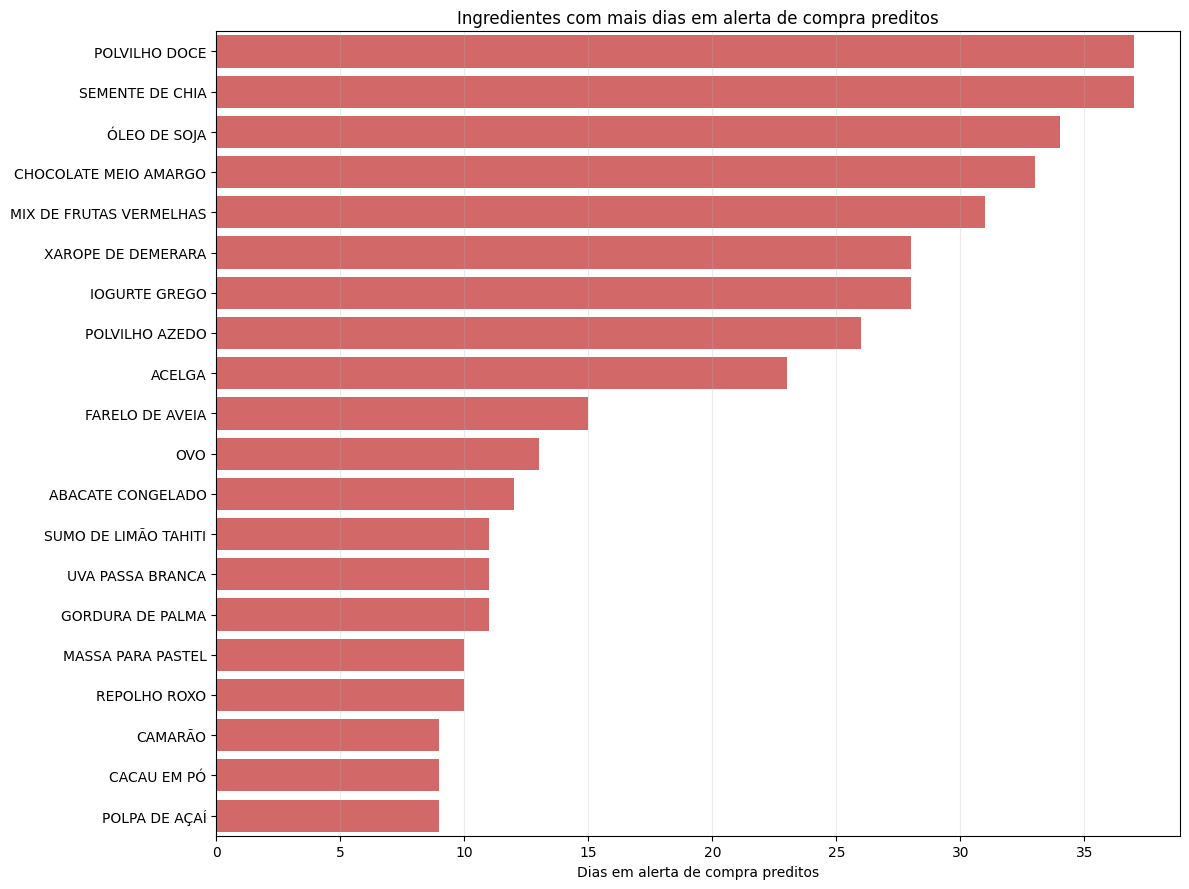

In [3]:
comparison = run_comparison_notebook()

print(f"Modelos PKL carregados: {comparison['models_loaded']}")
display(comparison["operational_metrics"])

## Recomendacoes operacionais detalhadas

In [4]:
display(comparison["operational_recommendations"].head(25))

,pipeline,stage,notebook,family,model,ingredient_id,date,nome_ingrediente,categoria,unidade,...,y_criticidade_nivel_ajustado,limiar_alerta_real_pct,limiar_alerta_predito_pct,limiar_critico_predito_pct,criticidade_real,criticidade_predita,probabilidade_alerta_compra,score_alerta_compra,necessita_compra,erro_limiar_alerta_pct
0,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0227,2026-03-30,GENGIBRE,Temperos e Especiarias,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN
1,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0104,2026-01-21,CEBOLA ROXA,Legumes e Verduras,KG,...,Alerta de compra,0.428571,NaN,NaN,Alerta de compra,Alerta de compra,0.89,0.89,True,NaN
2,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0110,2026-04-27,MIX DE COGUMELOS,Legumes e Verduras,KG,...,OK,0.357143,NaN,NaN,OK,OK,0.00,0.00,False,NaN
3,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0163,2026-01-05,OVO,Proteínas,UND,...,OK,0.357143,NaN,NaN,OK,OK,0.00,0.00,False,NaN
4,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0114,2026-03-30,REPOLHO ROXO,Legumes e Verduras,KG,...,OK,0.392857,NaN,NaN,OK,OK,0.00,0.00,False,NaN
5,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0111,2026-02-07,MIX DE FOLHAS,Legumes e Verduras,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN
6,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0016,2026-05-14,ESSÊNCIA DE BAUNILHA,Bebidas e Bases,L,...,OK,0.321429,NaN,NaN,OK,OK,0.00,0.00,False,NaN
7,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0166,2026-02-21,SALMÃO DEFUMADO,Proteínas,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN
8,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0133,2026-02-23,CASTANHA DE CAJU,Nozes e Sementes,KG,...,OK,0.392857,NaN,NaN,OK,OK,0.05,0.05,False,NaN
9,Arvores - purchase_alert_classification - Rand...,purchase_alert_classification,03_tree_ensembles,Arvores,Random Forest Classifier,ING0087,2026-03-06,LEITE EM PÓ,Laticínios,KG,...,OK,0.285714,NaN,NaN,OK,OK,0.00,0.00,False,NaN


## Divergencia por ingrediente no melhor modelo operacional

In [5]:
display(comparison["operational_by_ingredient"].head(25))

,pipeline,ingredient_id,nome_ingrediente,categoria,unidade,observacoes,dias_ok_preditos,dias_alerta_compra_preditos,dias_necessita_compra,cobertura_estoque_pct_min,cobertura_estoque_pct_media,limiar_alerta_predito_pct_medio,limiar_critico_predito_pct_medio,taxa_necessita_compra
0,Arvores - purchase_alert_classification - Rand...,ING0074,POLVILHO DOCE,"Grãos, Farinhas e Massas",KG,37,0,37,37,0.000000,0.033453,NaN,NaN,1.000000
1,Arvores - purchase_alert_classification - Rand...,ING0146,SEMENTE DE CHIA,Nozes e Sementes,KG,43,6,37,37,0.000000,0.341931,NaN,NaN,0.860465
2,Arvores - purchase_alert_classification - Rand...,ING0244,ÓLEO DE SOJA,Óleos e Gorduras,L,35,1,34,34,0.000000,0.072722,NaN,NaN,0.971429
3,Arvores - purchase_alert_classification - Rand...,ING0031,CHOCOLATE MEIO AMARGO,Chocolates e Cacau,KG,33,0,33,33,0.070131,0.103673,NaN,NaN,1.000000
4,Arvores - purchase_alert_classification - Rand...,ING0054,MIX DE FRUTAS VERMELHAS,Frutas Secas e Congeladas,KG,40,9,31,31,0.000000,0.334224,NaN,NaN,0.775000
5,Arvores - purchase_alert_classification - Rand...,ING0009,XAROPE DE DEMERARA,Açúcares e Mel,KG,28,0,28,28,0.000000,0.101756,NaN,NaN,1.000000
6,Arvores - purchase_alert_classification - Rand...,ING0085,IOGURTE GREGO,Laticínios,L,28,0,28,28,0.000000,0.042926,NaN,NaN,1.000000
7,Arvores - purchase_alert_classification - Rand...,ING0073,POLVILHO AZEDO,"Grãos, Farinhas e Massas",KG,26,0,26,26,0.000000,0.041996,NaN,NaN,1.000000
8,Arvores - purchase_alert_classification - Rand...,ING0098,ACELGA,Legumes e Verduras,KG,34,11,23,23,0.000000,0.350121,NaN,NaN,0.676471
9,Arvores - purchase_alert_classification - Rand...,ING0064,FARELO DE AVEIA,"Grãos, Farinhas e Massas",KG,22,7,15,15,0.000000,0.264635,NaN,NaN,0.681818


## Visualizacoes operacionais

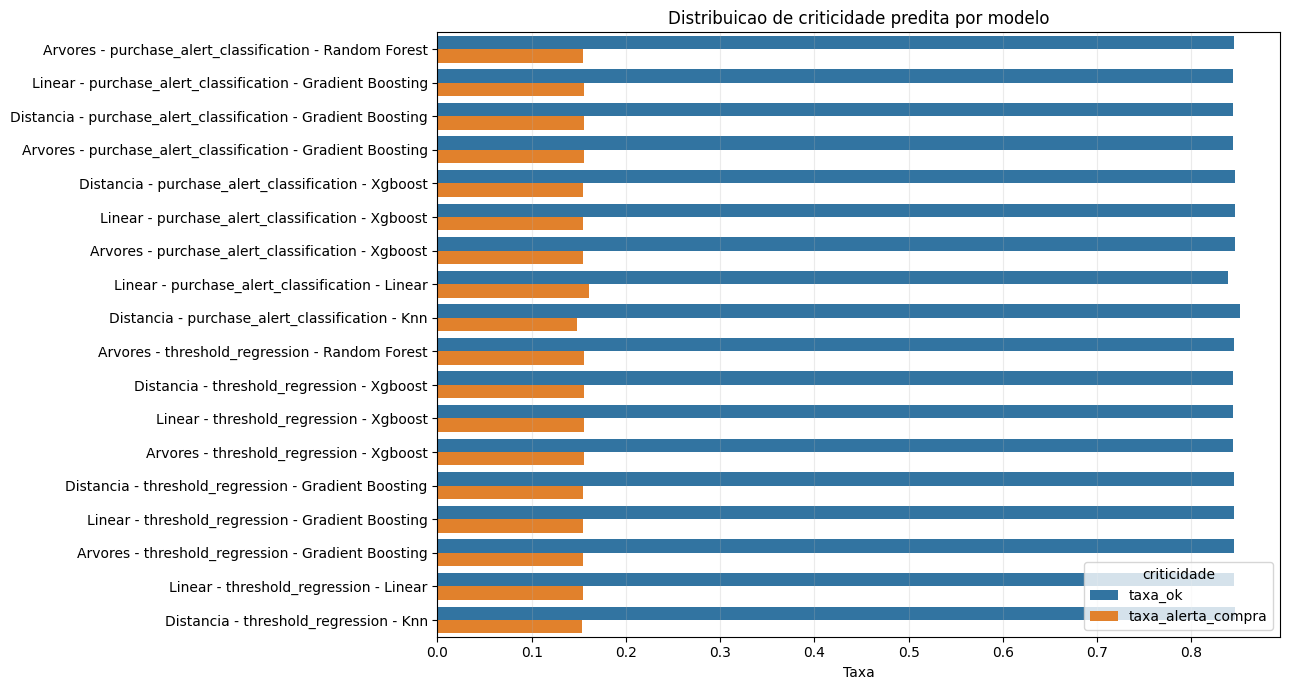

In [6]:
comparison["figures"]["criticality_distribution"]

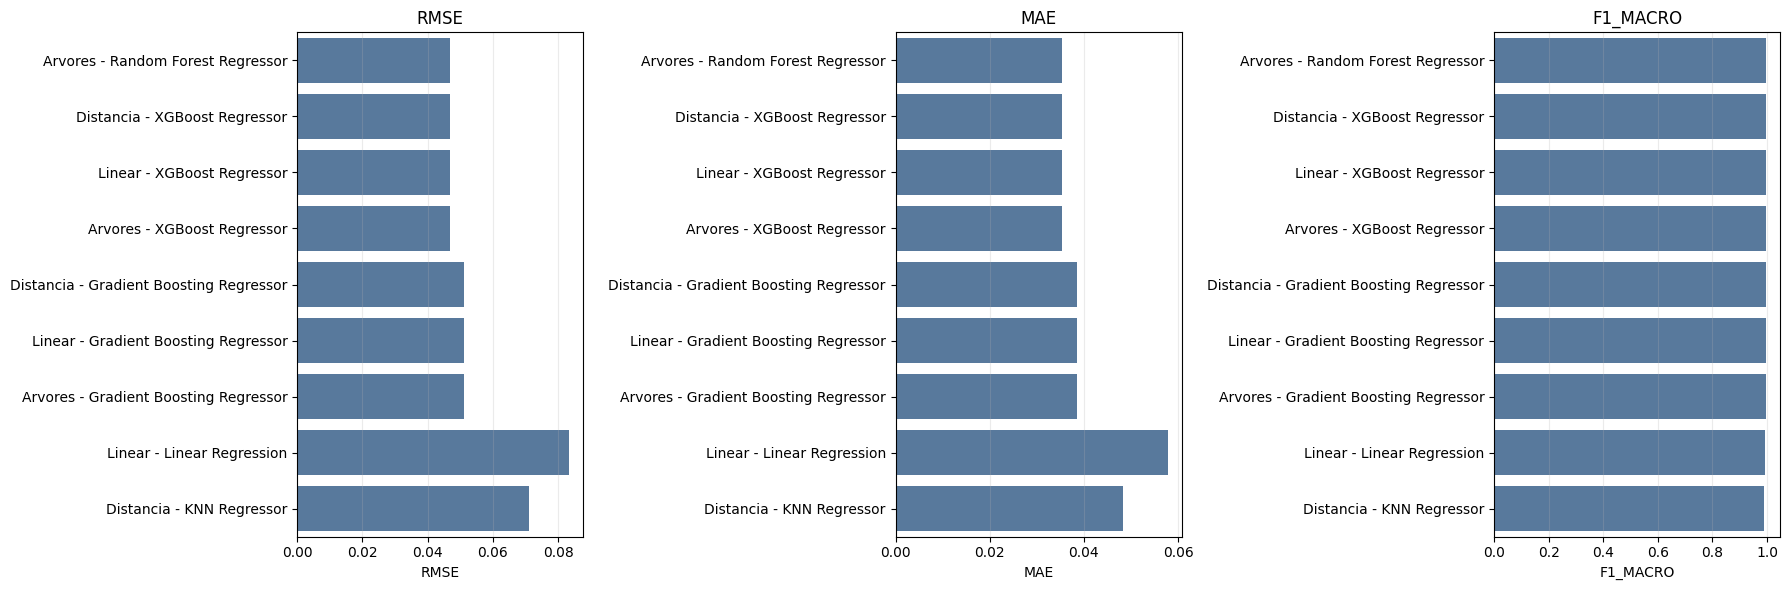

In [7]:
comparison["figures"]["threshold_metric_bars"]

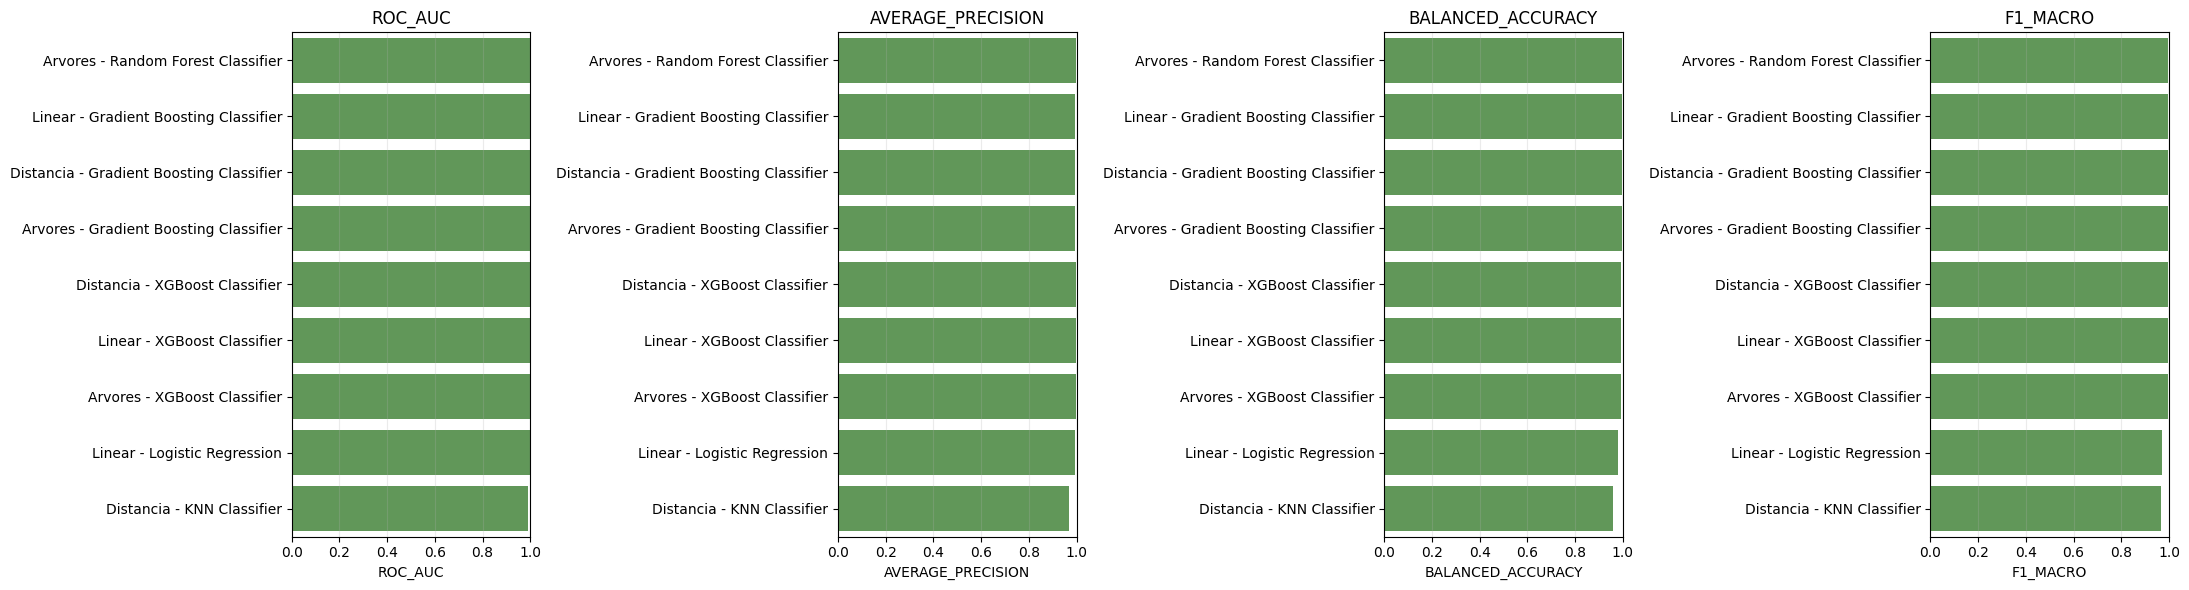

In [8]:
comparison["figures"]["classifier_metric_bars"]

## Curvas dos classificadores de alerta de compra


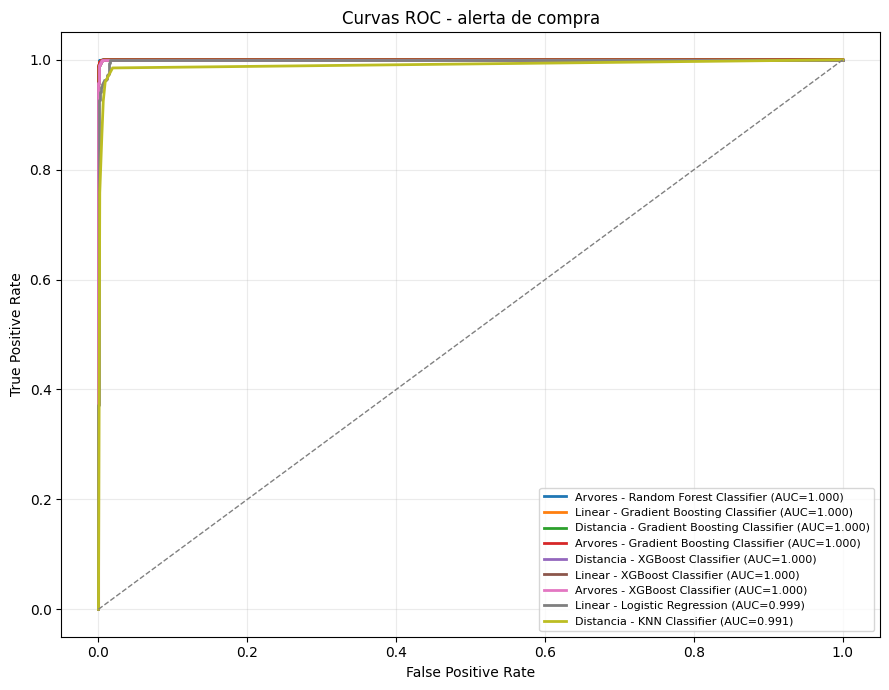

In [9]:
comparison["figures"]["purchase_alert_roc_curves"]

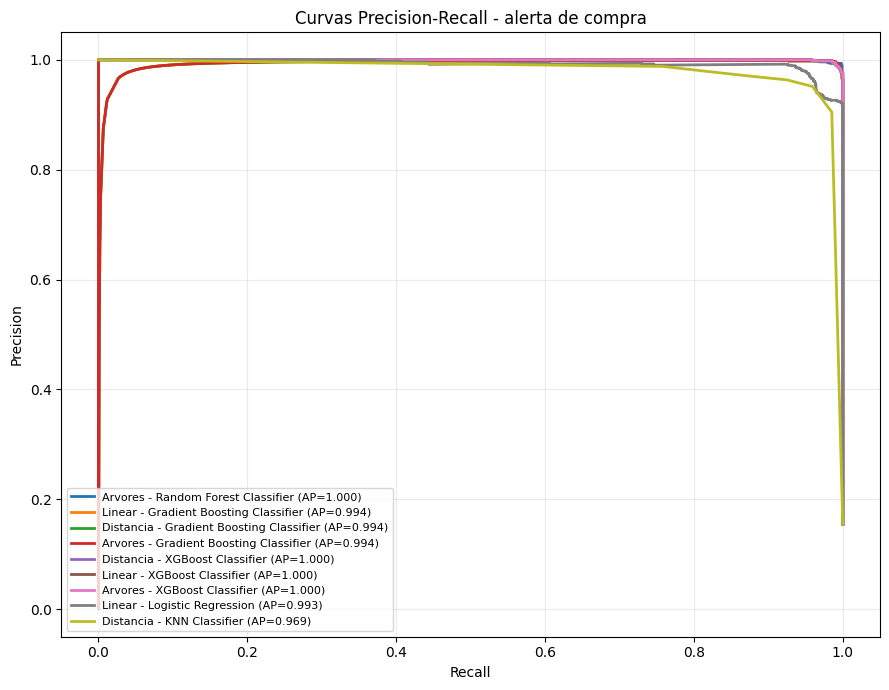

In [10]:
comparison["figures"]["purchase_alert_precision_recall_curves"]

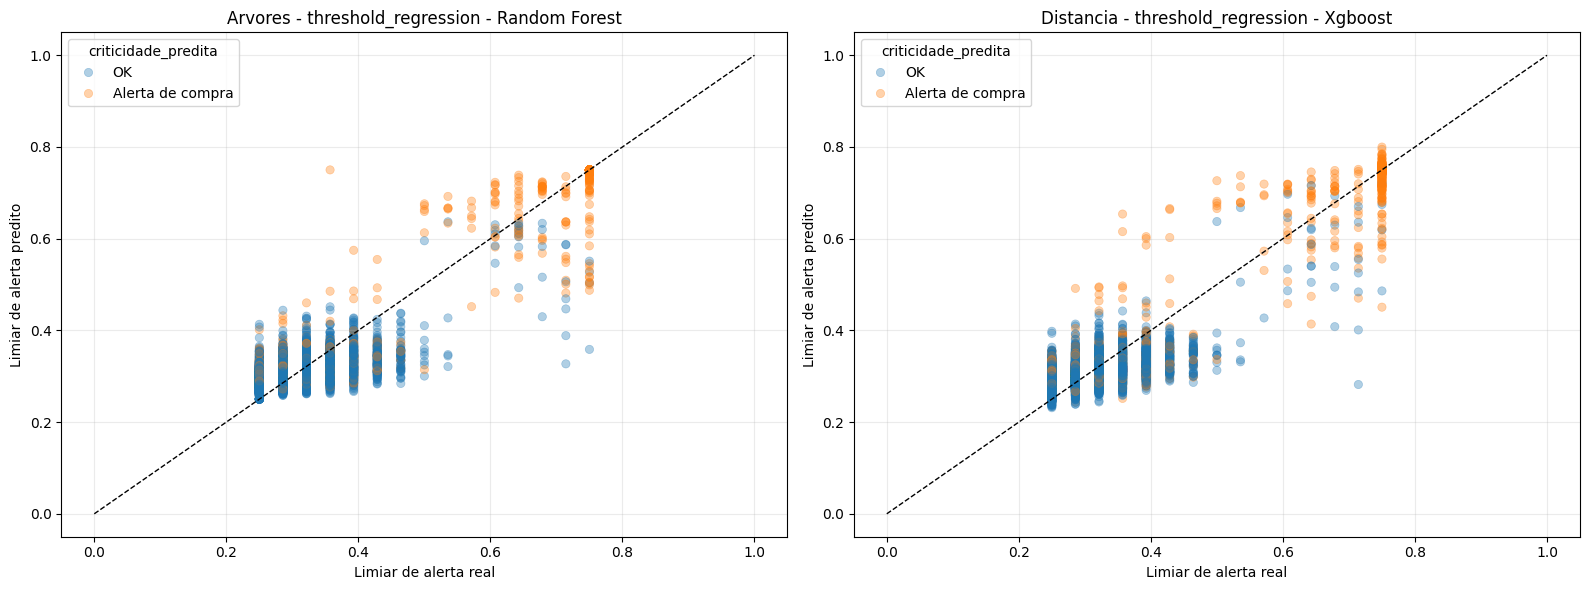

In [11]:
comparison["figures"]["threshold_scatter"]

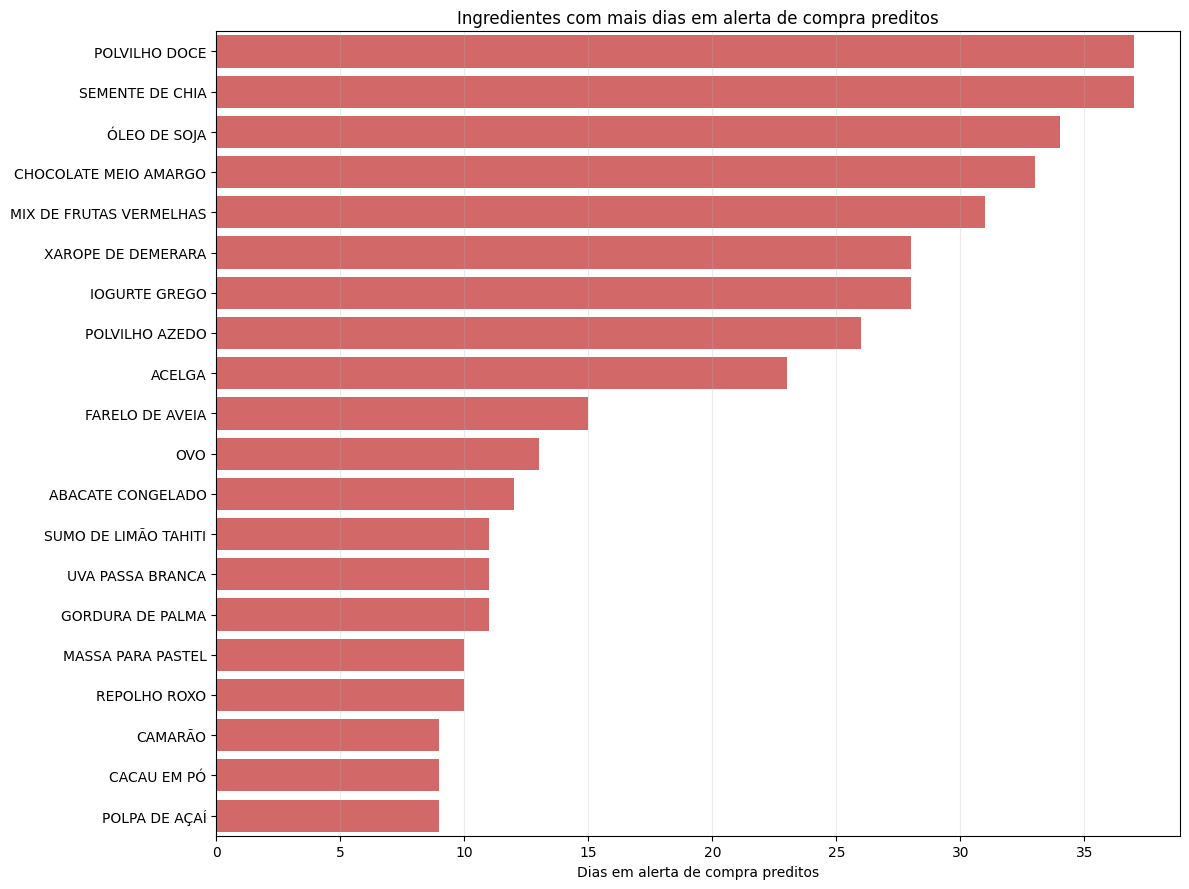

In [12]:
comparison["figures"]["top_critical_ingredients"]

## Metricas tecnicas de apoio

In [13]:
display(comparison["decision_table"])


,rank,notebook,family,stage,model,artifact_path,prediction_path,accuracy,f1_macro,precision_macro,...,taxa_ok,taxa_alerta_compra,taxa_necessita_compra,warnings,rmse,mae,r2,balanced_accuracy,roc_auc,average_precision
0,1,03_tree_ensembles,Arvores,purchase_alert_classification,Random Forest Classifier,ml/artifacts/two_stage/03_tree_ensembles_rando...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,0.997999,0.996173,0.996173,...,0.845318,0.154682,0.154682,NaN,NaN,NaN,NaN,0.996173,0.999961,0.999779
1,2,02_linear,Linear,purchase_alert_classification,Gradient Boosting Classifier,ml/artifacts/two_stage/02_linear_gradient_boos...,ml/artifacts/two_stage/metrics/02_linear_gradi...,0.997570,0.995362,0.994432,...,0.844603,0.155397,0.155397,NaN,NaN,NaN,NaN,0.996297,0.999796,0.994169
2,3,01_knn,Distancia,purchase_alert_classification,Gradient Boosting Classifier,ml/artifacts/two_stage/01_knn_gradient_boostin...,ml/artifacts/two_stage/metrics/01_knn_gradient...,0.997570,0.995362,0.994432,...,0.844603,0.155397,0.155397,NaN,NaN,NaN,NaN,0.996297,0.999796,0.994169
3,4,03_tree_ensembles,Arvores,purchase_alert_classification,Gradient Boosting Classifier,ml/artifacts/two_stage/03_tree_ensembles_gradi...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,0.997570,0.995362,0.994432,...,0.844603,0.155397,0.155397,NaN,NaN,NaN,NaN,0.996297,0.999796,0.994169
4,5,01_knn,Distancia,purchase_alert_classification,XGBoost Classifier,ml/artifacts/two_stage/01_knn_xgboost_classifi...,ml/artifacts/two_stage/metrics/01_knn_xgboost_...,0.997570,0.995345,0.996285,...,0.846033,0.153967,0.153967,NaN,NaN,NaN,NaN,0.994409,0.999960,0.999782
5,6,02_linear,Linear,purchase_alert_classification,XGBoost Classifier,ml/artifacts/two_stage/02_linear_xgboost_class...,ml/artifacts/two_stage/metrics/02_linear_xgboo...,0.997570,0.995345,0.996285,...,0.846033,0.153967,0.153967,NaN,NaN,NaN,NaN,0.994409,0.999960,0.999782
6,7,03_tree_ensembles,Arvores,purchase_alert_classification,XGBoost Classifier,ml/artifacts/two_stage/03_tree_ensembles_xgboo...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,0.997570,0.995345,0.996285,...,0.846033,0.153967,0.153967,NaN,NaN,NaN,NaN,0.994409,0.999960,0.999782
7,8,02_linear,Linear,purchase_alert_classification,Logistic Regression,ml/artifacts/two_stage/02_linear_logistic_regr...,ml/artifacts/two_stage/metrics/02_linear_logis...,0.985132,0.972056,0.964284,...,0.838742,0.161258,0.161258,NaN,NaN,NaN,NaN,0.980257,0.998877,0.992742
8,9,01_knn,Distancia,purchase_alert_classification,KNN Classifier,ml/artifacts/two_stage/01_knn_knn_classifier_p...,ml/artifacts/two_stage/metrics/01_knn_knn_clas...,0.982988,0.966934,0.974913,...,0.851465,0.148535,0.148535,NaN,NaN,NaN,NaN,0.959356,0.990533,0.969034
9,10,03_tree_ensembles,Arvores,threshold_regression,Random Forest Regressor,ml/artifacts/two_stage/03_tree_ensembles_rando...,ml/artifacts/two_stage/metrics/03_tree_ensembl...,0.998713,0.997543,0.996981,...,0.844889,0.155111,0.155111,NaN,0.046893,0.035387,0.775765,0.998106,NaN,NaN


## Visualizacoes tecnicas de criticidade


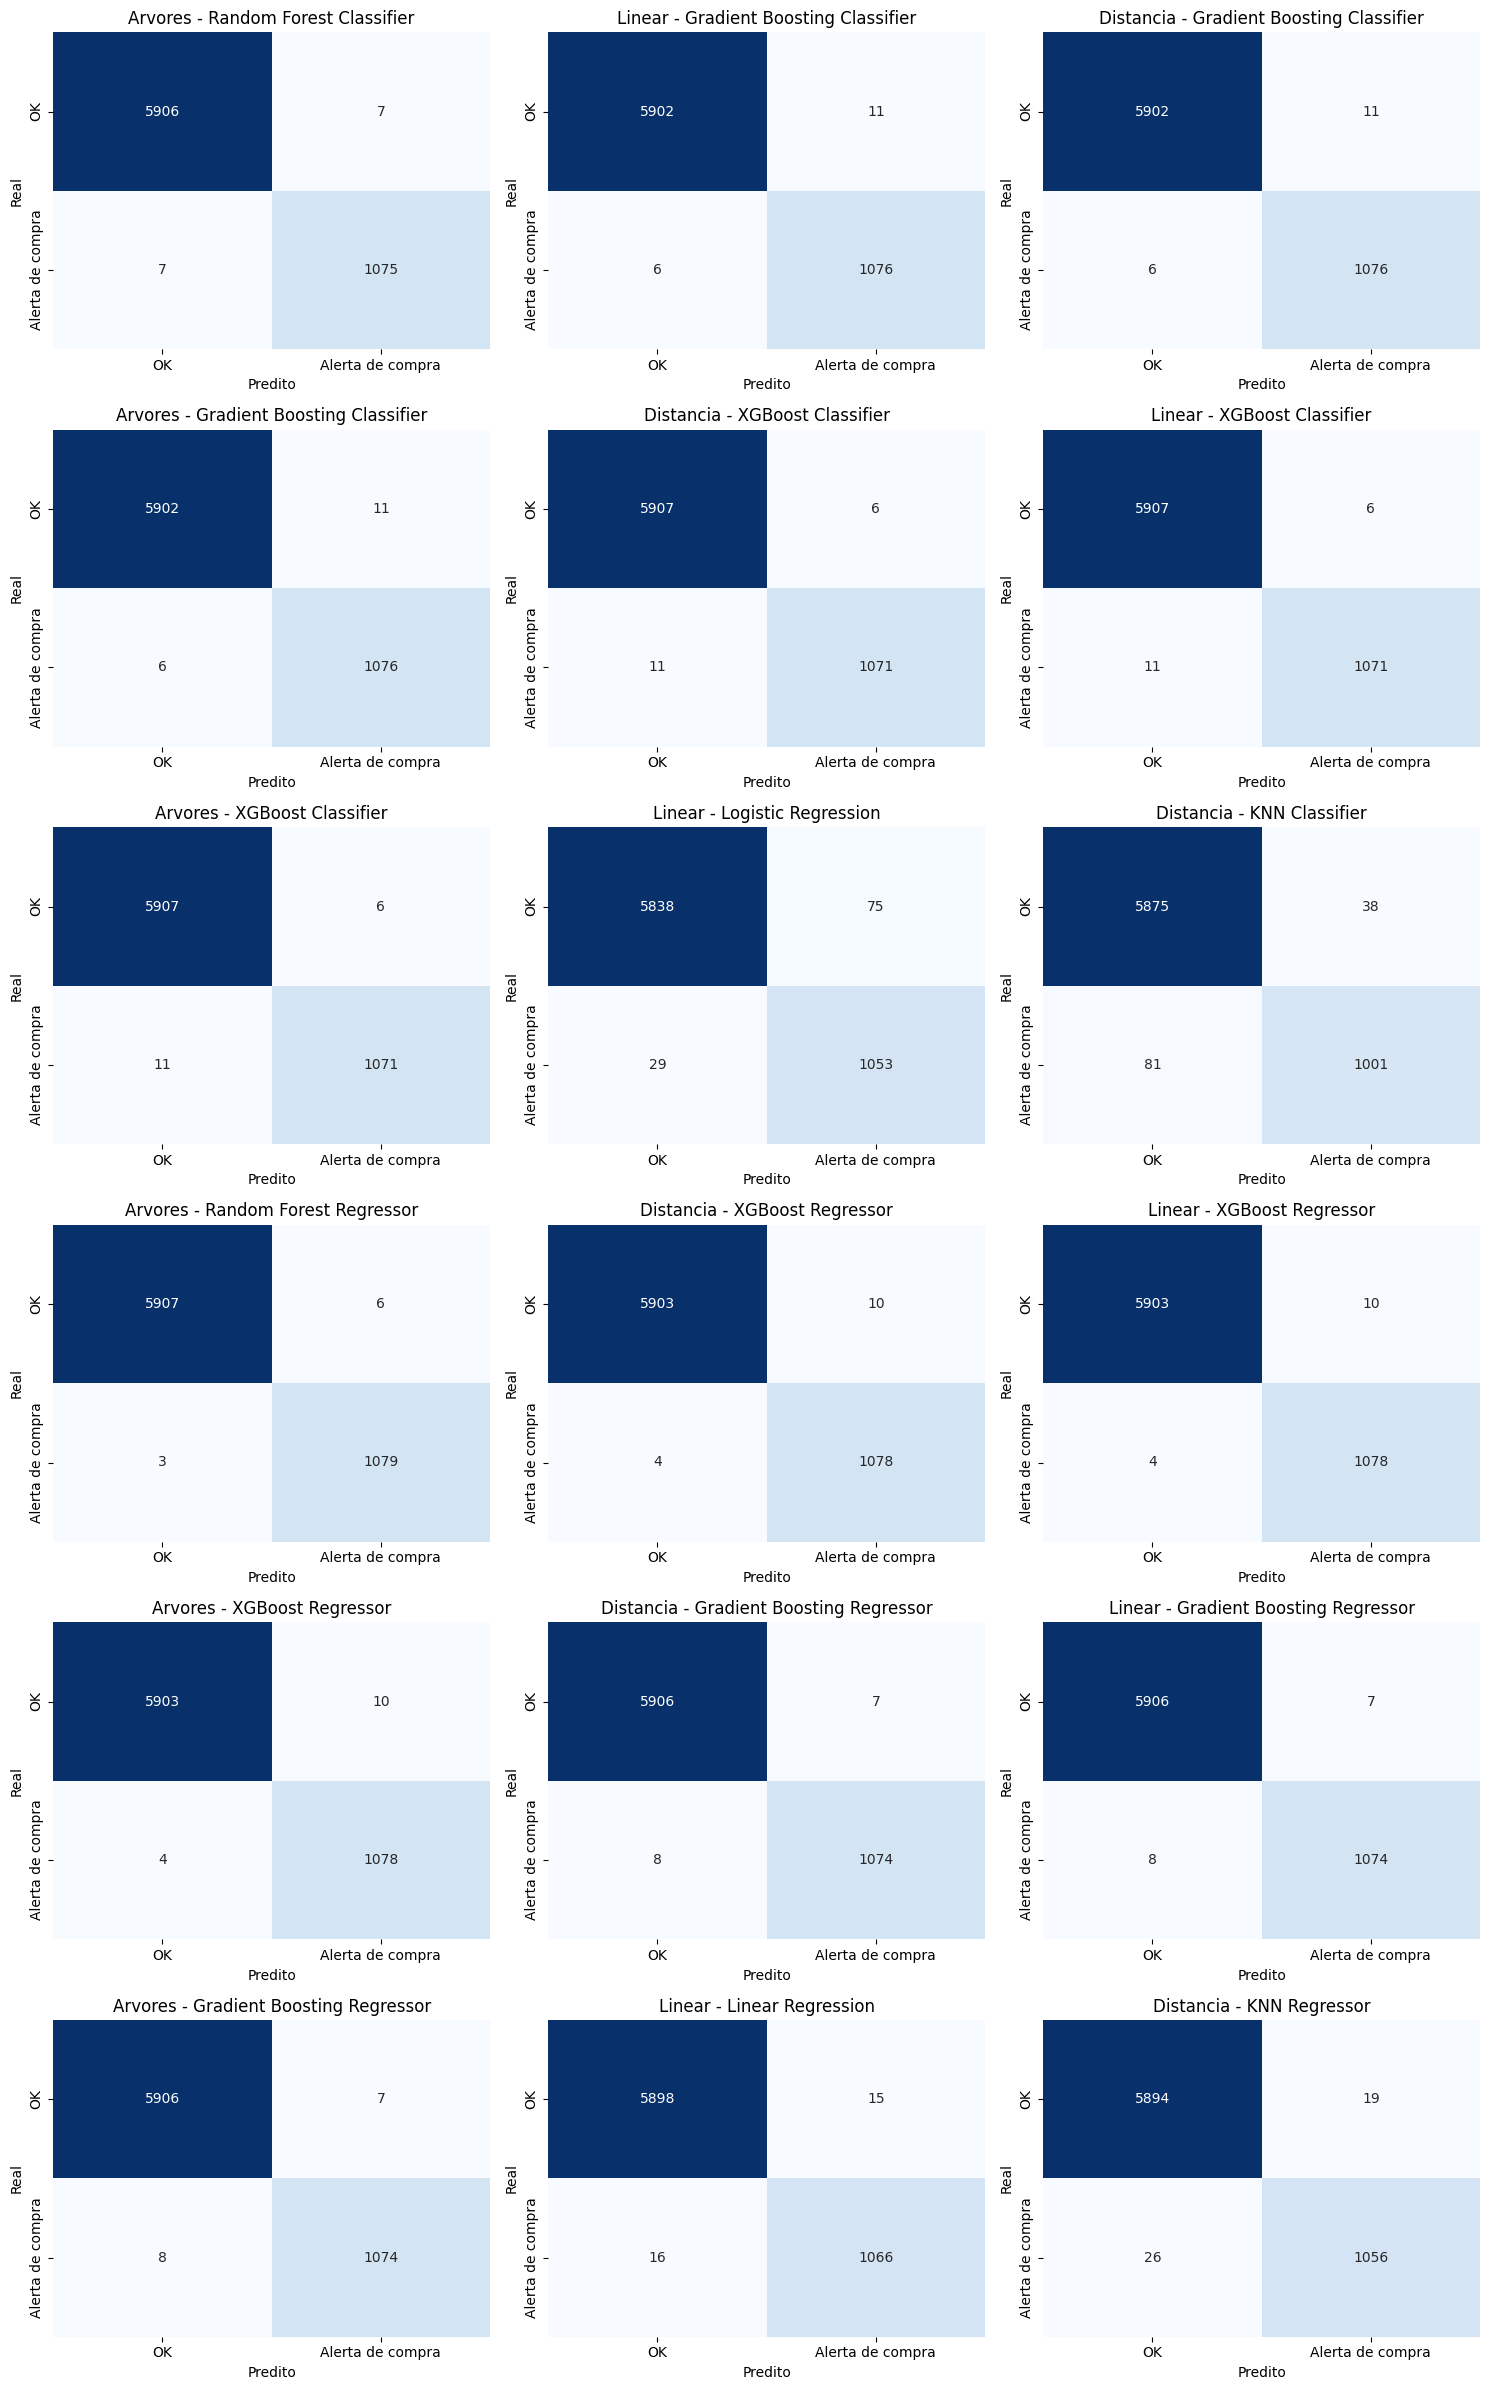

In [14]:
comparison["figures"]["confusion_matrices"]